## **Session 4** - Other GLMs for Classification
GLMs consist of three main components:

**Random Component:** This specifies the probability distribution of the target variable.
**Systematic Component:** This is the linear combination of predictors.
**Link Function:** This connects the random and systematic components.

general form of GLMs:

$g(E[Y|X]) = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p$

Where $g()$ is our link function, $E[Y|X]$ is the expected value of our target given our predictors, and the right side is our familiar linear combination of predictors.



### Multinomial Logistic Regression
این $GLM$ برای دسته بندی چیز هایی است که در بیش از دو دسته قرار می گیرند . درواقع نوع گسترش یافته و تعمیمی از $Logistic Regression$ است.

برای مثال میخواهیم مجموعه ای از عکس ها را دسته بندی کنیم که شامل ماشین و قطار و کشتی و ... است .

There are two main approaches to implementing multinomial logistic regression:

1. **One-vs-Rest (OvR)**
2. **Softmax (also known as multinomial)**

---

#### One-vs-Rest (OvR)
در این روش هر بار کل مسئله را به یک دسته بندی باینری ساده می شکنیم. یعنی، هر بار یکی از المان های مورد نظر (مثلا کشتی) را در نظر میگیریم و برای هر ورودی تصمیم میگیریم که آیا آن المان هست یا نه؟ (آیا کشتی است؟ یا نه؟)

> Train a classifier for each class

One-vs-Rest (OvR) is a strategy that involves training a separate binary classifier for each class in a multi-class problem.

1. For a problem with K classes, OvR trains K binary classifiers.
2. Each classifier is trained to distinguish one class from all others.
3. During prediction, all K classifiers are run on the input, and the class with the highest confidence score is chosen.

![](images/img_8.png)

![](images/img_9.png)


In [1]:
from sklearn.multiclass import OneVsRestClassifier # import
from sklearn.linear_model import LogisticRegression # import

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
iris = load_iris()
X = iris.data[:, [0, 1]]  # We'll use sepal length and sepal width
y = iris.target

In [4]:
#Scale the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

#Split the data
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)

In [8]:
import pandas as pd
pd.DataFrame(X_train).head()

,0,1
0,-0.416010,-1.513160
1,0.553333,-0.592373
2,0.674501,0.098217
3,0.916837,-0.131979
4,1.643844,1.249201


In [10]:
ovr_clf = OneVsRestClassifier(LogisticRegression()) #it needs a binary classifier. it could be any type
ovr_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeight

In [12]:
ovr_clf.estimators_

[LogisticRegression(), LogisticRegression(), LogisticRegression()]

In [20]:
ovr_clf.estimators_[0].coef_,ovr_clf.estimators_[1].coef_,ovr_clf.estimators_[2].coef_

(array([[-2.92692376,  1.90867906]]),
 array([[ 0.06583511, -1.43300872]]),
 array([[ 1.79151475, -0.1236019 ]]))

In [21]:
ovr_clf.predict(X_test)

array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0,
       0])

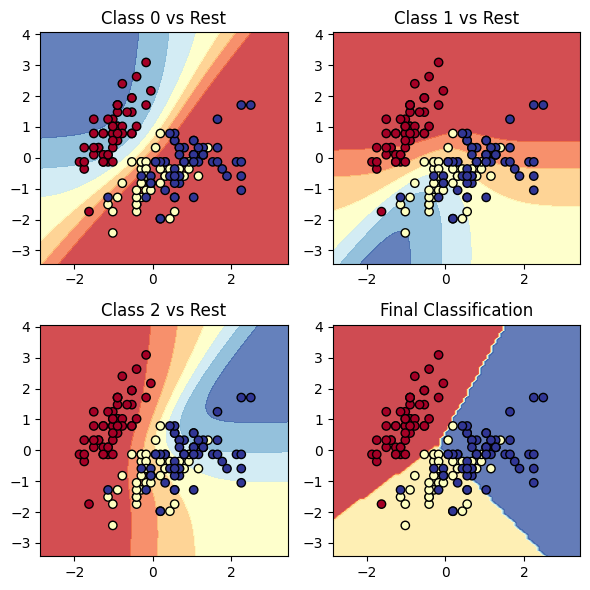

In [23]:
# Plotting function
def plot_ovr_decision_boundaries(X, y, clf):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    f, axarr = plt.subplots(2, 2, figsize=(6, 6))

    for idx, ax in enumerate(axarr.ravel()):
        if idx < 3:
            Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, idx]
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
            ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
            ax.set_title(f"Class {idx} vs Rest")
        else:
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
            ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
            ax.set_title("Final Classification")

    plt.tight_layout()
    plt.show()

plot_ovr_decision_boundaries(x_scaled, y, ovr_clf)

### Softmax Approach
فرض کن می‌خواهیم یک تصویر را در یکی از این 3 دسته قرار دهیم:

-  گربه
- سگ
 - پرنده

مدل در ابتدا برای هر کلاس یک عدد خام تولید می‌کند که به آن معمولاً Logit می‌گویند.

مثلا:
 - گربه:    2.0
- سگ:      1.0
- پرنده:  0.1

این اعداد هنوز $Probability$ (احتمال) نیستند، چون بین 0 و 1 نیستند مجموعشان برابر 1 نیست اینجاست که $Softmax Function$ وارد می‌شود.

$Softmax$ اعداد خام خروجی مدل را تبدیل می‌کند به احتمال.

برای مثال:
```
Probability:

گربه:    0.66 = 66%
سگ:      0.24 = 24%
پرنده:  0.10 = 10%
```
پس مدل می‌گوید من با احتمال 66٪ فکر می‌کنم این تصویر گربه است.

و در نهایت کلاسی که بیشترین احتمال را دارد انتخاب می‌شود: **گریه**

---

#### Softmax function

The softmax function is the key to extending logistic regression to multi-class problems.

The softmax function, also known as the normalized exponential function, is defined as:
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$



In [24]:
# define softmax function in python
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=0)

In multinomial logistic regression, we model the probability of an instance belonging to each of the $K$ classes. For each class $k$, we calculate:
$$P(Y=k|X) = \frac{e^{X\beta_k}}{\sum_{j=1}^K e^{X\beta_j}}$$

Where:

- $X$ is the input feature vector
- $\beta_k$ is the coefficient vector for class $k$
- $K$ is the total number of classes

![](images/img_10.png)

This function takes a vector of $K$ real numbers and normalizes it into a probability distribution.

---

#### Why we use *Softmax*?
چون در $Classification$ می‌خواهیم بدانیم:

**مدل چقدر به هر کلاس احتمال می‌دهد؟**

$Softmax$ کمک می‌کند خروجی مدل به یک توزیع احتمال تبدیل شود.

در این روش همه خروجی ها بین 0 و یک هستند و مجموع تمام احتمال ها برابر 1 است.

عدد بزرگ تر، احتمال بیشتری می گیرد.


---

#### Implementation

in *Scikit-Learn* you can use `LogisticRegression()` for softmax approach. `LogisticRegression()` work as *binomial classifier* for two classes, but *multi-class classifier* for more than two classes.



In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and prepare the Iris dataset
iris = load_iris()
X = iris.data[:, [0, 1]]  # We'll use sepal length and sepal width
y = iris.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Train Softmax model
softmax_clf = LogisticRegression()
softmax_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
softmax_clf.coef_

array([[-2.3203918 ,  1.32028183],
       [ 0.61047906, -0.96240838],
       [ 1.70991274, -0.35787345]])

#### Difference between **softmax** and **sigmoid**.
- **Sigmoid:**

    - برای $Binary Classification$ زیاد استفاده می‌شود.

- Softmax

    - برای چند کلاس استفاده می‌شود.


---

**Note:**
سافت مکس خودش تصمیم گیری نمی کند

فقط می گوید **احتمال هر کلاس چقدر است؟**

بعد معمولا از تابعی مثل $argmax$ استفاده می کنیم تا بزرگترین احتمال را حساب کنیم

> Softmax
>
> اعداد خام مدل را به احتمال تبدیل می‌کند، به‌طوری که مجموع احتمال تمام کلاس‌ها برابر 1 یا 100٪ باشد.

### One-vs-Rest (OvR) vs Softmax
Key Differences

1. **Decision Making:**

    - OvR: Makes multiple binary decisions
    - Softmax: Makes a single multi-class decision
2. **Probability Interpretation:**

    - OvR: Confidence scores may not sum to 1
    - Softmax: Probabilities always sum to 1
3. **Class Relationships:**

    - OvR: Treats each class independently
    - Softmax: Considers relationships between classes


 **Note:** In practice, both methods often perform similarly, but Softmax tends to provide more intuitive probability estimates and can capture more complex class relationships.



### Probit Regression
Probit regression is another powerful tool in our GLM toolkit, particularly useful for binary classification problems.

The probit model uses the inverse of the cumulative distribution function (CDF) of the standard normal distribution as its link function.

In mathematical terms, the probit link function is:

$$g(\mu) = \Phi^{-1}(\mu)$$

Where $\Phi^{-1}$ is the inverse of the standard normal CDF, also known as the probit function.

visualize the standard normal CDF and its inverse (the probit function):

![](images/img_11.png)

#### Comparison with Logistic Regression

1. **Link Function:**

    - Logistic: Uses the logit function $\log(\frac{\mu}{1-\mu})$

    - Probit: Uses the inverse normal CDF $\Phi^{-1}(\mu)$
2. **Interpretation:**

    - Logistic: Coefficients represent changes in log-odds
    - Probit: Coefficients represent changes in z-scores
3. **Tail Behavior:**

    - Logistic: Has slightly heavier tails
    - Probit: Tails approach zero more quickly




### Ordinal Regression
رگرسیون ترتیبی زمانی استفاده می‌شود که متغیر هدف، دسته‌بندی‌شده و دارای ترتیب واضح و معناداری باشد.

Imagine you're developing a model to predict customer satisfaction levels:

1. Very Unsatisfied
2. Unsatisfied
3. Neutral
4. Satisfied
5. Very Satisfied

these categories have a clear order. Unlike multinomial logistic regression

Ordinal regression is particularly useful in scenarios like rating predictions, severity assessments, or any situation where the outcome has ranked categories.

---

#### How it Works?
Ordinal regression models the cumulative probabilities of the ordered categories. Instead of predicting the probability of each category directly, it predicts the probability of being in a particular category or any category below it.

The model uses a series of threshold points (also called cut points or intercepts) to divide the continuous latent variable into ordered categories.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# define the thresholds
thresholds = [-1.5, -0.5, 0.5, 1.5]
categories = ["Very unsatisfied", "Unsatisfied", "Neutral", "Satisfied", "Very satisfied"]

In [3]:
# Create a range of values
x = np.linspace(-3, 3, 1000)
y = norm.pdf(x, 0, 1)

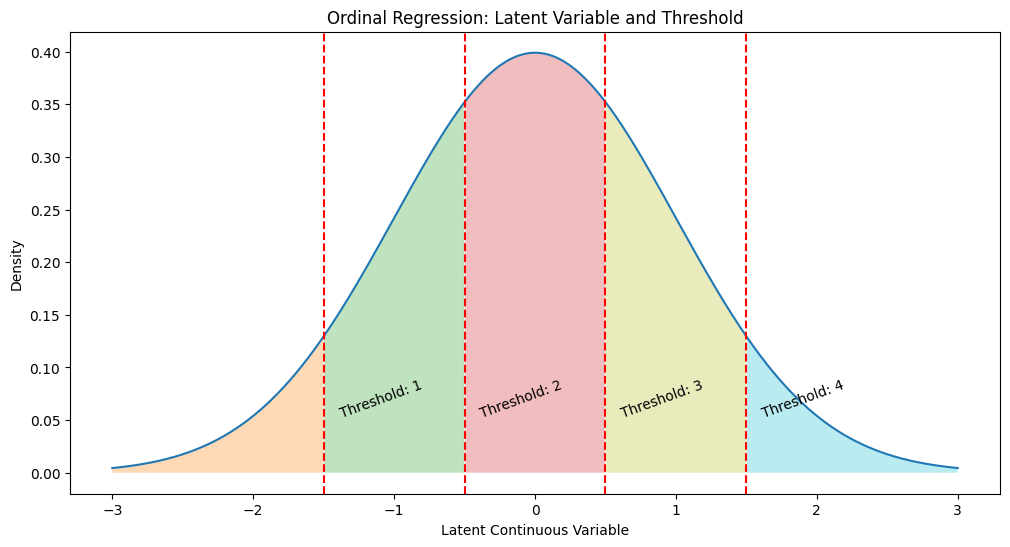

In [18]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.fill_between(x, y , where= (x < thresholds[0]), facecolor=('C1'), alpha=0.3)
plt.fill_between(x, y , where= ((x >= thresholds[0]) & (x < thresholds[1])), facecolor=('C2'), alpha=0.3)
plt.fill_between(x, y , where= ((x >= thresholds[1]) & (x < thresholds[2])), facecolor=('C3'), alpha=0.3)
plt.fill_between(x, y , where= ((x >= thresholds[2]) & (x < thresholds[3])), facecolor=('C8'), alpha=0.3)
plt.fill_between(x, y , where= (x >= thresholds[3]), facecolor=('C9'), alpha=0.3)

for i, thresh in enumerate(thresholds):
    plt.axvline(x=thresh, color='r', linestyle='--')
    plt.text(thresh + 0.1, 0.05, f"Threshold: {i + 1}", color='k', rotation=20, verticalalignment='bottom')

plt.title("Ordinal Regression: Latent Variable and Threshold")
plt.xlabel("Latent Continuous Variable")
plt.ylabel("Density")
plt.show()

**Note:** Ordinal regression is not supported in *Scikit-Learn*. you can use it from *statsmodel* library
```
from statsmodels.miscmodels.ordinal_model import OrderedModel
```

### Choosing the Right GLM for Classification
1. **Nature of the Target Variable**

    - Binary: Logistic Regression
    - Multi-class (unordered): Multinomial Logistic Regression
    - Multi-class (ordered): Ordinal Regression
2. **Distribution of the Data**

    - Symmetric: Consider Probit Regression
    - Asymmetric: Consider Complementary Log-Log
3.  **Sample Size and Number of Features**

    - Large sample, many features: Logistic Regression often works well
    - Small sample: Simpler models or regularized versions
3. **Interpretability Requirements**

    - High interpretability needed: Logistic Regression, Probit Regression
    - Complex relationships allowed: Consider non-linear extensions or machine learning alternatives

---

#### Decision Framework
```
Is the target variable binary?
|
|-- Yes: Consider Logistic Regression
|   |
|   Is the data symmetric?
|   |-- Yes: Logistic Regression or Probit Regression
|   |-- No: Consider Complementary Log-Log
|
|-- No: Is the target variable ordinal?
    |
    |-- Yes: Use Ordinal Regression
    |
    |-- No: Use Multinomial Logistic Regression
```
